# Analyse exploratoire des donnees du dataset UCI Heart Disease

## Objectifs du notebook

Ce notebook prepare la future phase de modelisation en se limitant a l'analyse exploratoire et a la preparation methodologique.

Les objectifs sont les suivants :
- charger les donnees a partir des fichiers locaux UCI ;
- reconstruire une base fusionnee avec une colonne `source` ;
- verifier la structure reelle des donnees et la qualite des codages ;
- analyser les valeurs manquantes, la cible `num` et les distributions des variables ;
- comparer les hopitaux / sous-bases ;
- interpreter les resultats obtenus ;
- preparer la suite du projet sans lancer encore la modelisation finale.


In [20]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    import missingno as msno
    HAS_MISSINGNO = True
except ImportError:
    HAS_MISSINGNO = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


## 1. Chargement des donnees a partir des fichiers bruts locaux

Dans cette version du notebook, on n'utilise plus `ucimlrepo` comme source principale. La raison est simple : pour ce projet, la priorite est de maitriser explicitement la fusion des differentes bases (`cleveland`, `hungarian`, `switzerland`, `va`) et de conserver l'information multiclasse de la cible lorsque celle-ci est presente dans les fichiers bruts.

La documentation UCI indique que chaque fichier brut contient **76 attributs** organises selon le meme schema, et que les 14 variables classiques du probleme correspondent aux positions suivantes : `3, 4, 9, 10, 12, 16, 19, 32, 38, 40, 41, 44, 51, 58`.


In [21]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path.resolve() for path in candidate_roots if (path / "data").exists()), Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data"

raw_files = {
    "cleveland": "cleveland.data",
    "hungarian": "hungarian.data",
    "switzerland": "switzerland.data",
    "va": "long-beach-va.data",
}

processed_fallback_files = {
    "cleveland": "processed.cleveland.data",
}

attribute_positions = {
    "age": 3,
    "sex": 4,
    "cp": 9,
    "trestbps": 10,
    "chol": 12,
    "fbs": 16,
    "restecg": 19,
    "thalach": 32,
    "exang": 38,
    "oldpeak": 40,
    "slope": 41,
    "ca": 44,
    "thal": 51,
    "num": 58,
}

column_names = list(attribute_positions.keys())
selected_indices = [position - 1 for position in attribute_positions.values()]
missing_markers = {"-9", "-9.", "?"}

print(f"Current working directory: {Path.cwd()}")
print(f"Project root used in this notebook: {PROJECT_ROOT}")
print(f"Data directory detected: {DATA_DIR}")

attribute_map = pd.DataFrame({
    "variable": column_names,
    "uci_position": list(attribute_positions.values()),
    "zero_based_index": selected_indices,
})
display(attribute_map)


Current working directory: c:\Users\titou\DOSSIER\ENSAI\Erasmus\cours\MachineLearning2\projetML2\code_projetML2\notebooks
Project root used in this notebook: C:\Users\titou\DOSSIER\ENSAI\Erasmus\cours\MachineLearning2\projetML2\code_projetML2
Data directory detected: C:\Users\titou\DOSSIER\ENSAI\Erasmus\cours\MachineLearning2\projetML2\code_projetML2\data


,variable,uci_position,zero_based_index
0,age,3,2
1,sex,4,3
2,cp,9,8
3,trestbps,10,9
4,chol,12,11
5,fbs,16,15
6,restecg,19,18
7,thalach,32,31
8,exang,38,37
9,oldpeak,40,39


### Variables de travail

Les 14 variables retenues pour l'analyse sont les suivantes :

- `age` : age du patient
- `sex` : sexe (`1` = homme, `0` = femme)
- `cp` : type de douleur thoracique
- `trestbps` : pression arterielle au repos
- `chol` : cholesterolemie
- `fbs` : glycemie a jeun > 120 mg/dl
- `restecg` : electrocardiogramme au repos
- `thalach` : frequence cardiaque maximale atteinte
- `exang` : angine induite par l'exercice
- `oldpeak` : depression ST induite par l'exercice
- `slope` : pente du segment ST a l'effort
- `ca` : nombre de vaisseaux principaux colores par fluoroscopie
- `thal` : statut thalassemique / type de defaut perfusionnel
- `num` : cible originale UCI avec classes `0, 1, 2, 3, 4`


In [22]:
def parse_raw_source(path, column_names, selected_indices, encoding="latin1"):
    with path.open("r", encoding=encoding, errors="replace") as f:
        lines = [line.strip() for line in f if line.strip()]

    raw_records = []
    for start in range(0, len(lines), 10):
        chunk = lines[start:start + 10]
        if len(chunk) < 10:
            raise ValueError(f"Incomplete block detected in {path.name} starting at line {start}.")

        tokens = []
        for line in chunk:
            tokens.extend(line.split())

        if len(tokens) != 76:
            raise ValueError(
                f"Expected 76 tokens in {path.name} at block starting line {start}, got {len(tokens)}."
            )

        raw_records.append([tokens[index] for index in selected_indices])

    return pd.DataFrame(raw_records, columns=column_names)


def clean_selected_table(df_selected):
    df_clean = df_selected.replace({marker: np.nan for marker in missing_markers}).copy()
    for col in column_names:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
    return df_clean


raw_selected_frames = []
clean_frames = []
loading_status = []

for source, filename in raw_files.items():
    raw_path = DATA_DIR / filename

    try:
        df_selected_raw = parse_raw_source(raw_path, column_names, selected_indices)
        loader_used = "raw"
        file_used = filename
        note = "raw file parsed successfully"
    except Exception as exc:
        fallback_name = processed_fallback_files.get(source)
        if fallback_name is None:
            raise

        file_used = fallback_name
        loader_used = "processed fallback"
        note = f"raw file unusable locally ({type(exc).__name__})"
        df_selected_raw = pd.read_csv(DATA_DIR / fallback_name, names=column_names, dtype=str)

    df_selected_raw["source"] = source
    raw_selected_frames.append(df_selected_raw.copy())

    df_source = clean_selected_table(df_selected_raw[column_names])
    df_source["source"] = source
    clean_frames.append(df_source)

    loading_status.append({
        "source": source,
        "file_used": file_used,
        "loader_used": loader_used,
        "rows": len(df_source),
        "note": note,
    })

df_raw_selected = pd.concat(raw_selected_frames, ignore_index=True)
df = pd.concat(clean_frames, ignore_index=True)
df["source"] = df["source"].astype("category")

loading_report = pd.DataFrame(loading_status)
special_missing_counts = (
    df_raw_selected[column_names]
    .isin(missing_markers)
    .sum()
    .rename("n_special_missing")
    .to_frame()
)

display(loading_report)
display(df.head())
print(f"Working dataset shape: {df.shape}")


,source,file_used,loader_used,rows,note
0,cleveland,processed.cleveland.data,processed fallback,303,raw file unusable locally (ValueError)
1,hungarian,hungarian.data,raw,294,raw file parsed successfully
2,switzerland,switzerland.data,raw,123,raw file parsed successfully
3,va,long-beach-va.data,raw,200,raw file parsed successfully


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,cleveland
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,cleveland
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,cleveland
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,cleveland
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,cleveland


Working dataset shape: (920, 15)


## 2. Verification de la structure reelle des donnees

Une fois la table fusionnee reconstruite, on verifie :
- le nombre d'observations et de variables ;
- les types `pandas` ;
- la separation entre variables quantitatives et qualitatives codees numeriquement ;
- la disponibilite effective de la colonne `source`.


In [23]:
target_col = "num"
source_col = "source"
quantitative_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
binary_features = ["sex", "fbs", "exang"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
all_feature_columns = quantitative_features + categorical_features

variable_roles = pd.DataFrame({
    "variable": column_names + [source_col],
    "pandas_dtype": [str(df[col].dtype) for col in column_names] + [str(df[source_col].dtype)],
    "role": [
        "quantitative" if col in quantitative_features else
        "categorical coded as numeric" if col in categorical_features else
        "target"
        for col in column_names
    ] + ["source identifier"]
})

print(f"Number of rows   : {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
display(pd.DataFrame({"variable": df.columns}))
display(variable_roles)
display(df[source_col].value_counts().sort_index().rename("count").to_frame())

df.info()


Number of rows   : 920
Number of columns: 15


,variable
0,age
1,sex
2,cp
3,trestbps
4,chol
5,fbs
6,restecg
7,thalach
8,exang
9,oldpeak


,variable,pandas_dtype,role
0,age,float64,quantitative
1,sex,float64,categorical coded as numeric
2,cp,float64,categorical coded as numeric
3,trestbps,float64,quantitative
4,chol,float64,quantitative
5,fbs,float64,categorical coded as numeric
6,restecg,float64,categorical coded as numeric
7,thalach,float64,quantitative
8,exang,float64,categorical coded as numeric
9,oldpeak,float64,quantitative


,count
source,
cleveland,303
hungarian,294
switzerland,123
va,200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       920 non-null    float64 
 1   sex       920 non-null    float64 
 2   cp        920 non-null    float64 
 3   trestbps  861 non-null    float64 
 4   chol      890 non-null    float64 
 5   fbs       830 non-null    float64 
 6   restecg   918 non-null    float64 
 7   thalach   865 non-null    float64 
 8   exang     865 non-null    float64 
 9   oldpeak   858 non-null    float64 
 10  slope     612 non-null    float64 
 11  ca        310 non-null    float64 
 12  thal      443 non-null    float64 
 13  num       920 non-null    int64   
 14  source    920 non-null    category
dtypes: category(1), float64(13), int64(1)
memory usage: 101.8 KB


## 3. Nettoyage preliminaire, valeurs manquantes et controle des codages

Le nettoyage preliminaire ne se limite pas a remplacer les marqueurs de donnees manquantes. Avec des fichiers bruts UCI, il faut aussi verifier si les modalites effectivement observees correspondent bien a la documentation. Cette etape est importante pour eviter de traiter comme des categories cliniques valides des codes qui sont en realite des valeurs aberrantes ou des conventions propres a certaines bases.


Number of duplicated rows: 2


,n_missing,pct_missing,n_special_missing
ca,610,0.663,610
thal,477,0.518,477
slope,308,0.335,308
fbs,90,0.098,90
oldpeak,62,0.067,62
trestbps,59,0.064,59
thalach,55,0.060,55
exang,55,0.060,55
chol,30,0.033,30
restecg,2,0.002,2


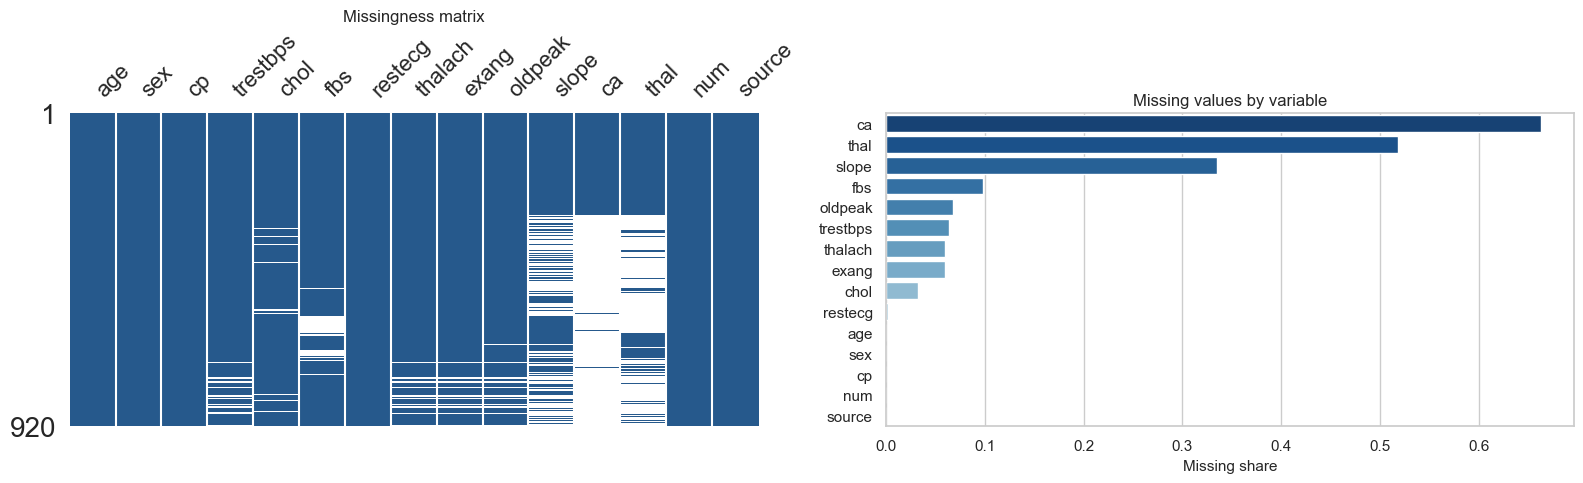

In [24]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_rows}")

missing_table = df.isna().sum().rename("n_missing").to_frame()
missing_table["pct_missing"] = missing_table["n_missing"] / len(df)
missing_table = missing_table.join(special_missing_counts, how="left").fillna(0)
missing_table["n_special_missing"] = missing_table["n_special_missing"].astype(int)
missing_table = missing_table.sort_values(["pct_missing", "n_missing"], ascending=False)
display(missing_table)

fig, axes = plt.subplots(1, 2 if HAS_MISSINGNO else 1, figsize=(16 if HAS_MISSINGNO else 8, 5))

if HAS_MISSINGNO:
    msno.matrix(df, color=(0.15, 0.35, 0.55), sparkline=False, ax=axes[0])
    axes[0].set_title("Missingness matrix")
    sns.barplot(data=missing_table.reset_index(), x="pct_missing", y="index", ax=axes[1], palette="Blues_r")
    axes[1].set_xlabel("Missing share")
    axes[1].set_ylabel("")
    axes[1].set_title("Missing values by variable")
else:
    ax = axes if not isinstance(axes, np.ndarray) else axes[0]
    sns.barplot(data=missing_table.reset_index(), x="pct_missing", y="index", ax=ax, palette="Blues_r")
    ax.set_xlabel("Missing share")
    ax.set_ylabel("")
    ax.set_title("Missing values by variable")

plt.tight_layout()


In [25]:
documented_modalities = {
    "sex": {0, 1},
    "cp": {1, 2, 3, 4},
    "fbs": {0, 1},
    "restecg": {0, 1, 2},
    "exang": {0, 1},
    "slope": {1, 2, 3},
    "ca": {0, 1, 2, 3},
    "thal": {3, 6, 7},
    "num": {0, 1, 2, 3, 4},
}

modality_audit_rows = []
for col, expected_values in documented_modalities.items():
    observed_values = sorted({int(value) if float(value).is_integer() else value for value in df[col].dropna().unique()})
    unexpected_values = [value for value in observed_values if value not in expected_values]
    modality_audit_rows.append({
        "variable": col,
        "expected": sorted(expected_values),
        "observed": observed_values,
        "unexpected": unexpected_values,
    })

modality_audit = pd.DataFrame(modality_audit_rows)
display(modality_audit)

source_modalities = {}
for col in ["slope", "ca", "thal"]:
    source_modalities[col] = pd.crosstab(df[source_col], df[col], dropna=False)

for col, table in source_modalities.items():
    print(f"Observed values by source for {col}")
    display(table)


,variable,expected,observed,unexpected
0,sex,"[0, 1]","[0, 1]",[]
1,cp,"[1, 2, 3, 4]","[1, 2, 3, 4]",[]
2,fbs,"[0, 1]","[0, 1]",[]
3,restecg,"[0, 1, 2]","[0, 1, 2]",[]
4,exang,"[0, 1]","[0, 1]",[]
5,slope,"[1, 2, 3]","[0, 1, 2, 3]",[0]
6,ca,"[0, 1, 2, 3]","[0, 1, 2, 3, 9]",[9]
7,thal,"[3, 6, 7]","[1, 2, 3, 4, 5, 6, 7]","[1, 2, 4, 5]"
8,num,"[0, 1, 2, 3, 4]","[0, 1, 2, 3, 4]",[]


Observed values by source for slope


slope,0.000,1.000,2.000,3.000
source,,,,
cleveland,0,142,140,21
hungarian,0,12,91,1
switzerland,0,33,61,12
va,1,16,53,29


Observed values by source for ca


ca,0.000,1.000,2.000,3.000,9.000
source,,,,,
cleveland,176,65,38,20,0
hungarian,3,0,0,0,1
switzerland,0,2,3,0,0
va,2,0,0,0,0


Observed values by source for thal


thal,1.000,2.000,3.000,4.000,5.000,6.000,7.000
source,,,,,,,
cleveland,0,0,166,0,0,18,117
hungarian,0,0,7,0,0,10,11
switzerland,1,0,19,1,0,10,42
va,3,1,4,0,3,8,22


### Commentaire intermediaire

L'EDA met en evidence deux difficultes majeures avant modelisation :
- un manque d'information tres important sur certaines variables (`ca`, `thal`, `slope`) ;
- des heterogeneites de codage dans les fichiers bruts, par exemple `ca = 9`, `slope = 0` ou des modalites non documentees de `thal`.

Ces points devront etre traites explicitement dans le pipeline de pretraitement, et pas seulement laisses a l'imputation par defaut.


## 4. Analyse de la variable cible

La variable `num` est au coeur du projet. Le point important ici est que l'usage des fichiers bruts permet de conserver une cible multiclasse plus fidele au probleme initial, notamment pour la base hongroise, alors que certaines versions `processed` simplifient deja ce codage.


,count,proportion
num,,
0,411,0.447
1,196,0.213
2,135,0.147
3,135,0.147
4,43,0.047


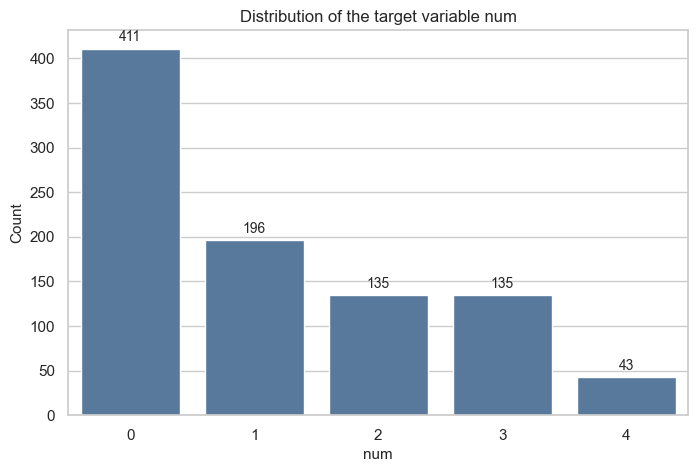

Preview of a future binary target (0 vs 1-4):


,count,proportion
num,,
0,411,0.447
1,509,0.553


In [26]:
target_summary = df[target_col].value_counts().sort_index().rename("count").to_frame()
target_summary["proportion"] = target_summary["count"] / len(df)
display(target_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=target_summary.index.astype(str), y=target_summary["count"], color="#4C78A8", ax=ax)

for i, value in enumerate(target_summary["count"]):
    ax.text(i, value + 5, str(int(value)), ha="center", va="bottom", fontsize=10)

ax.set_xlabel("num")
ax.set_ylabel("Count")
ax.set_title("Distribution of the target variable num")
plt.show()

binary_preview = df[target_col].gt(0).map({False: 0, True: 1}).value_counts().sort_index().rename("count").to_frame()
binary_preview["proportion"] = binary_preview["count"] / len(df)
print("Preview of a future binary target (0 vs 1-4):")
display(binary_preview)


### Discussion sur la faisabilite multiclasse

La cible multiclasse est ici plus realiste que dans une version deja binarisee du dataset. Les classes `1`, `2` et `3` disposent d'effectifs non negligeables, alors que la classe `4` reste clairement minoritaire. Une classification multiclasse est donc defendable et pedagogiquement interessante, mais elle demandera une evaluation soigneuse et une attention particuliere au desequilibre des classes.

En parallele, il reste pertinent de preparer une version binaire `0` vs `1-4` afin de comparer les deux formulations du probleme dans la suite du projet.


## 5. Analyse univariee

Cette partie decrit la distribution de chaque variable de facon individuelle. Elle sert a repérer les asymetries, les valeurs extremes, les categories rares et les distributions tres lacunaires.


,count,mean,std,min,25%,50%,75%,max
age,920.000,53.511,9.425,28.000,47.000,54.000,60.000,77.000
trestbps,861.000,132.132,19.066,0.000,120.000,130.000,140.000,200.000
chol,890.000,199.130,110.781,0.000,175.000,223.000,268.000,603.000
thalach,865.000,137.546,25.926,60.000,120.000,140.000,157.000,202.000
oldpeak,858.000,0.879,1.091,-2.600,0.000,0.500,1.500,6.200


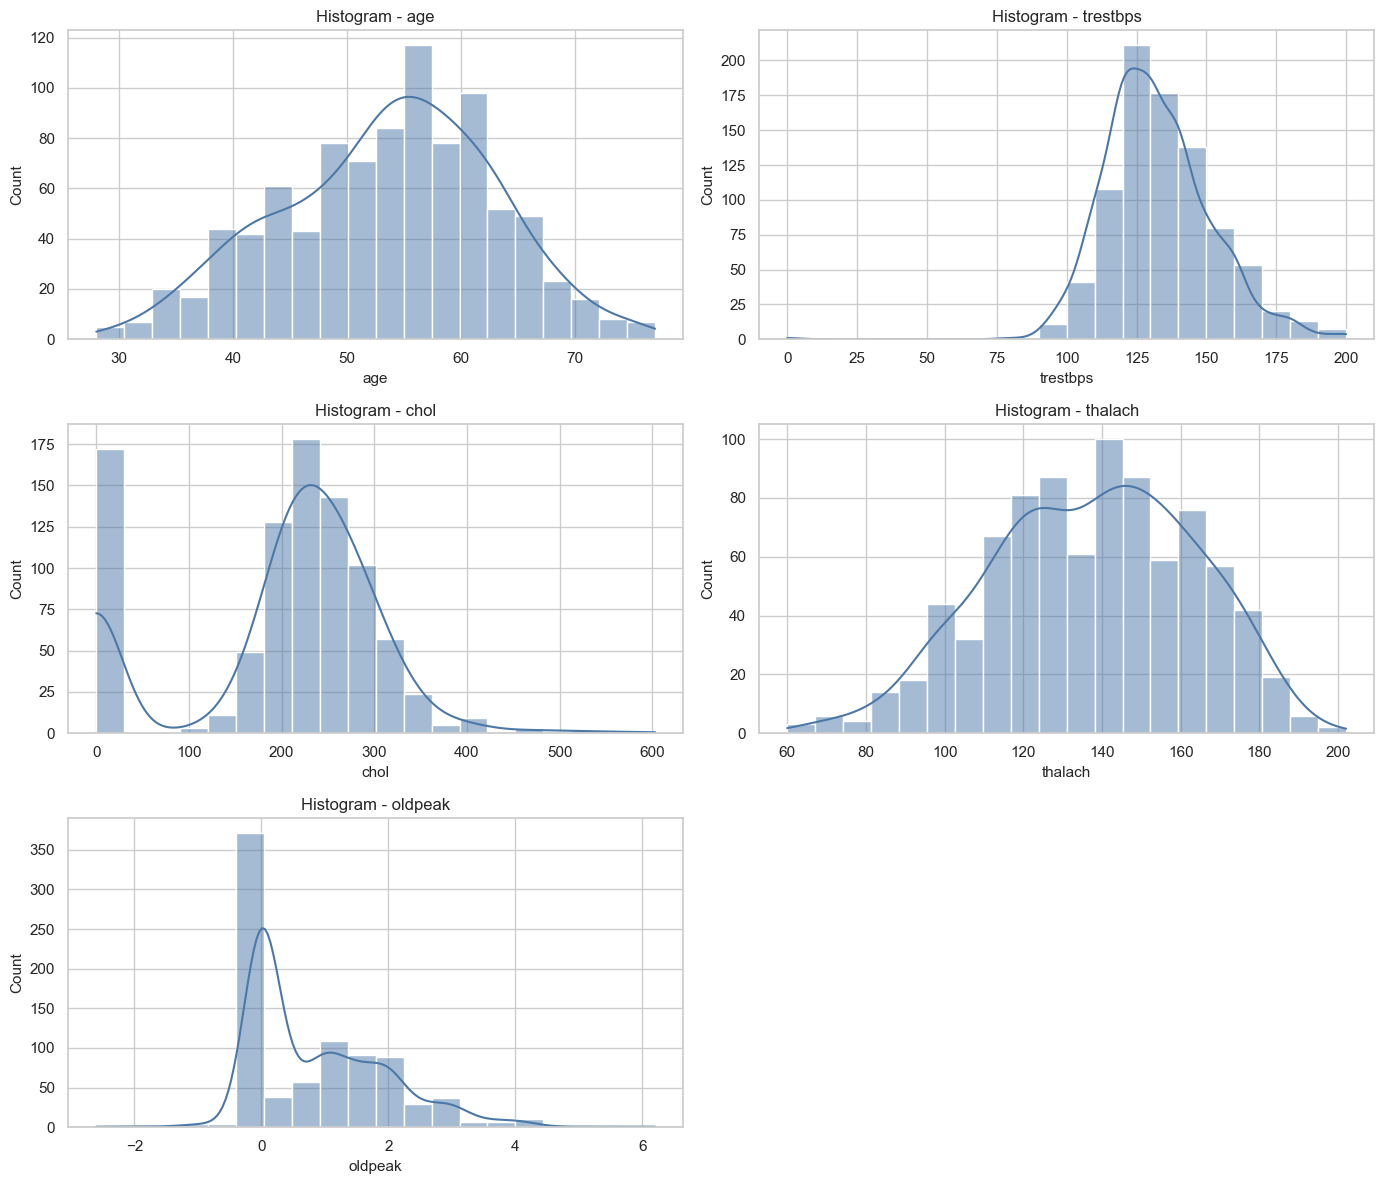

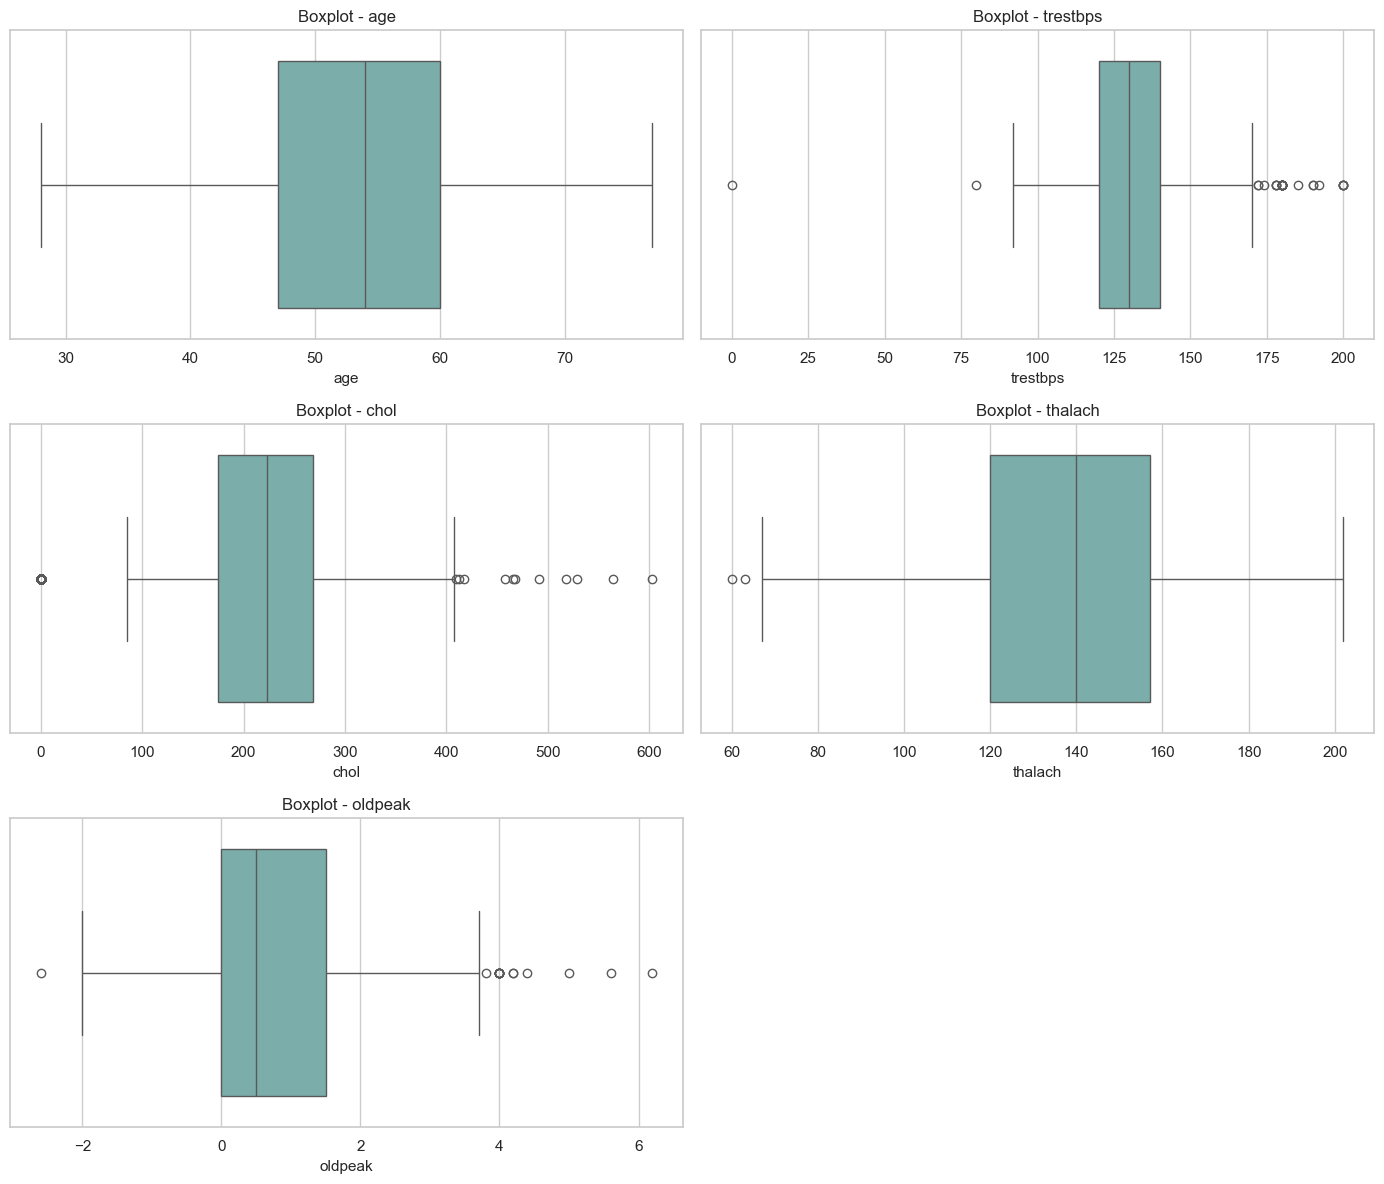

In [27]:
display(df[quantitative_features].describe().T)

ncols = 2
nrows = int(np.ceil(len(quantitative_features) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, quantitative_features):
    sns.histplot(df[col], kde=True, bins=20, color="#4C78A8", ax=ax)
    ax.set_title(f"Histogram - {col}")
    ax.set_xlabel(col)

for ax in axes[len(quantitative_features):]:
    ax.set_visible(False)

plt.tight_layout()

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, quantitative_features):
    sns.boxplot(x=df[col], color="#72B7B2", ax=ax)
    ax.set_title(f"Boxplot - {col}")
    ax.set_xlabel(col)

for ax in axes[len(quantitative_features):]:
    ax.set_visible(False)

plt.tight_layout()


,sex,count,proportion
0,0,194,0.211
1,1,726,0.789


,cp,count,proportion
0,1,46,0.050
1,2,174,0.189
2,3,204,0.222
3,4,496,0.539


,fbs,count,proportion
0,0,692,0.752
1,1,138,0.150
2,Missing,90,0.098


,restecg,count,proportion
0,0,551,0.599
1,1,179,0.195
2,2,188,0.204
3,Missing,2,0.002


,exang,count,proportion
0,0,528,0.574
1,1,337,0.366
2,Missing,55,0.060


,slope,count,proportion
0,0,1,0.001
1,1,203,0.221
2,2,345,0.375
3,3,63,0.068
4,Missing,308,0.335


,ca,count,proportion
0,0,181,0.197
1,1,67,0.073
2,2,41,0.045
3,3,20,0.022
4,9,1,0.001
5,Missing,610,0.663


,thal,count,proportion
0,1,4,0.004
1,2,1,0.001
2,3,196,0.213
3,4,1,0.001
4,5,3,0.003
5,6,46,0.050
6,7,192,0.209
7,Missing,477,0.518


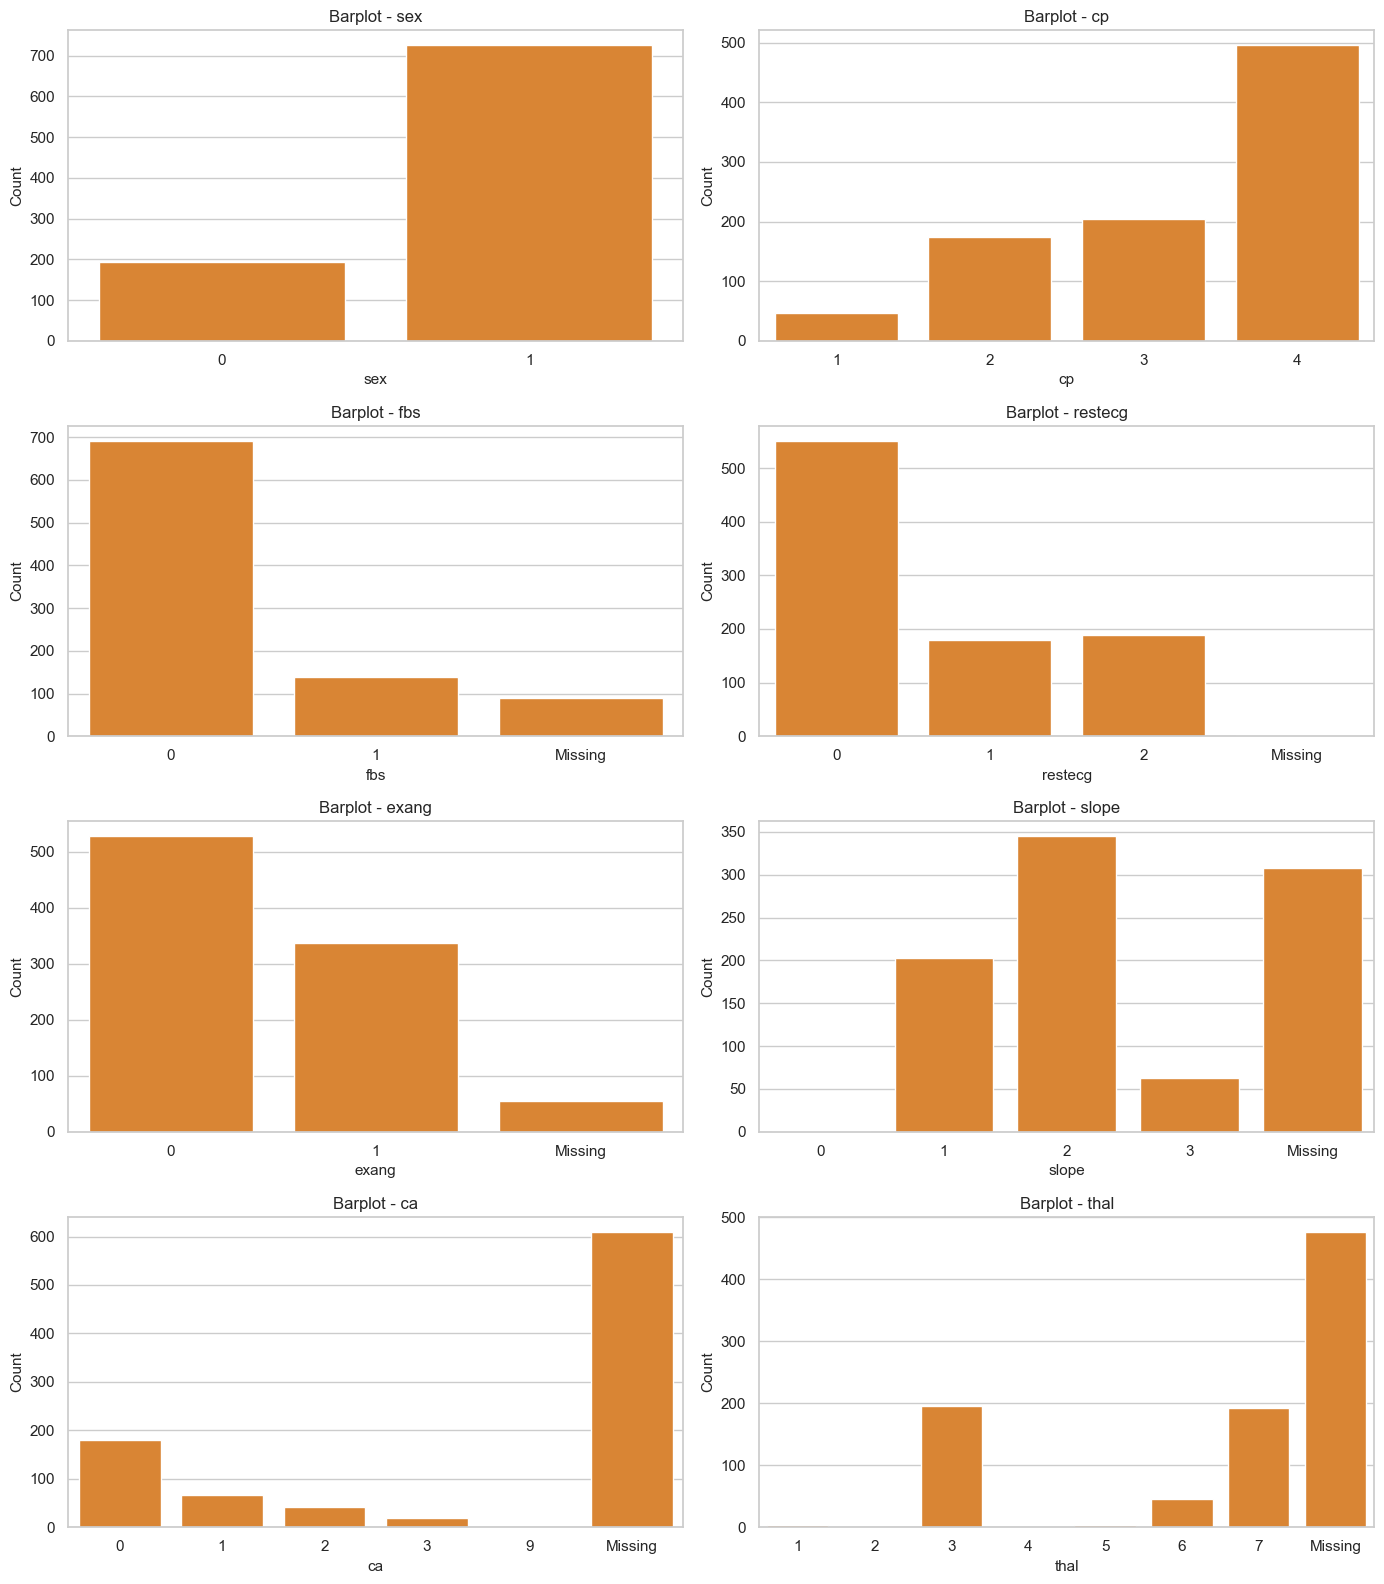

In [28]:
def prepare_categorical_plot_data(series):
    formatted = series.astype("Int64").astype(str).replace("<NA>", "Missing")
    observed_labels = [label for label in formatted.unique().tolist() if label != "Missing"]
    ordered_labels = sorted(observed_labels, key=lambda value: int(value))
    if "Missing" in formatted.values:
        ordered_labels.append("Missing")
    return formatted, ordered_labels


categorical_summaries = {}
for col in categorical_features:
    formatted, order = prepare_categorical_plot_data(df[col])
    summary = formatted.value_counts(dropna=False).reindex(order).rename_axis(col).reset_index(name="count")
    summary["proportion"] = summary["count"] / len(df)
    categorical_summaries[col] = summary
    display(summary)

ncols = 2
nrows = int(np.ceil(len(categorical_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, categorical_features):
    formatted, order = prepare_categorical_plot_data(df[col])
    sns.countplot(x=formatted, order=order, color="#F58518", ax=ax)
    ax.set_title(f"Barplot - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()


### Commentaire intermediaire

L'analyse univariee aide a distinguer les variables plutot stables des variables problematiques. Dans ce dataset, la lecture des distributions doit rester liee a la qualite des codages : une categorie rare peut correspondre a un phenomene clinique reel, mais aussi a un codage non documente ou a une specificite de source.


## 6. Analyse bivariee avec la cible

Cette partie cherche a mettre en relation les covariables et la cible `num`, sans encore construire de modele. L'objectif est d'identifier les signaux cliniquement plausibles et les variables qui pourraient etre discriminantes dans une future modelisation.


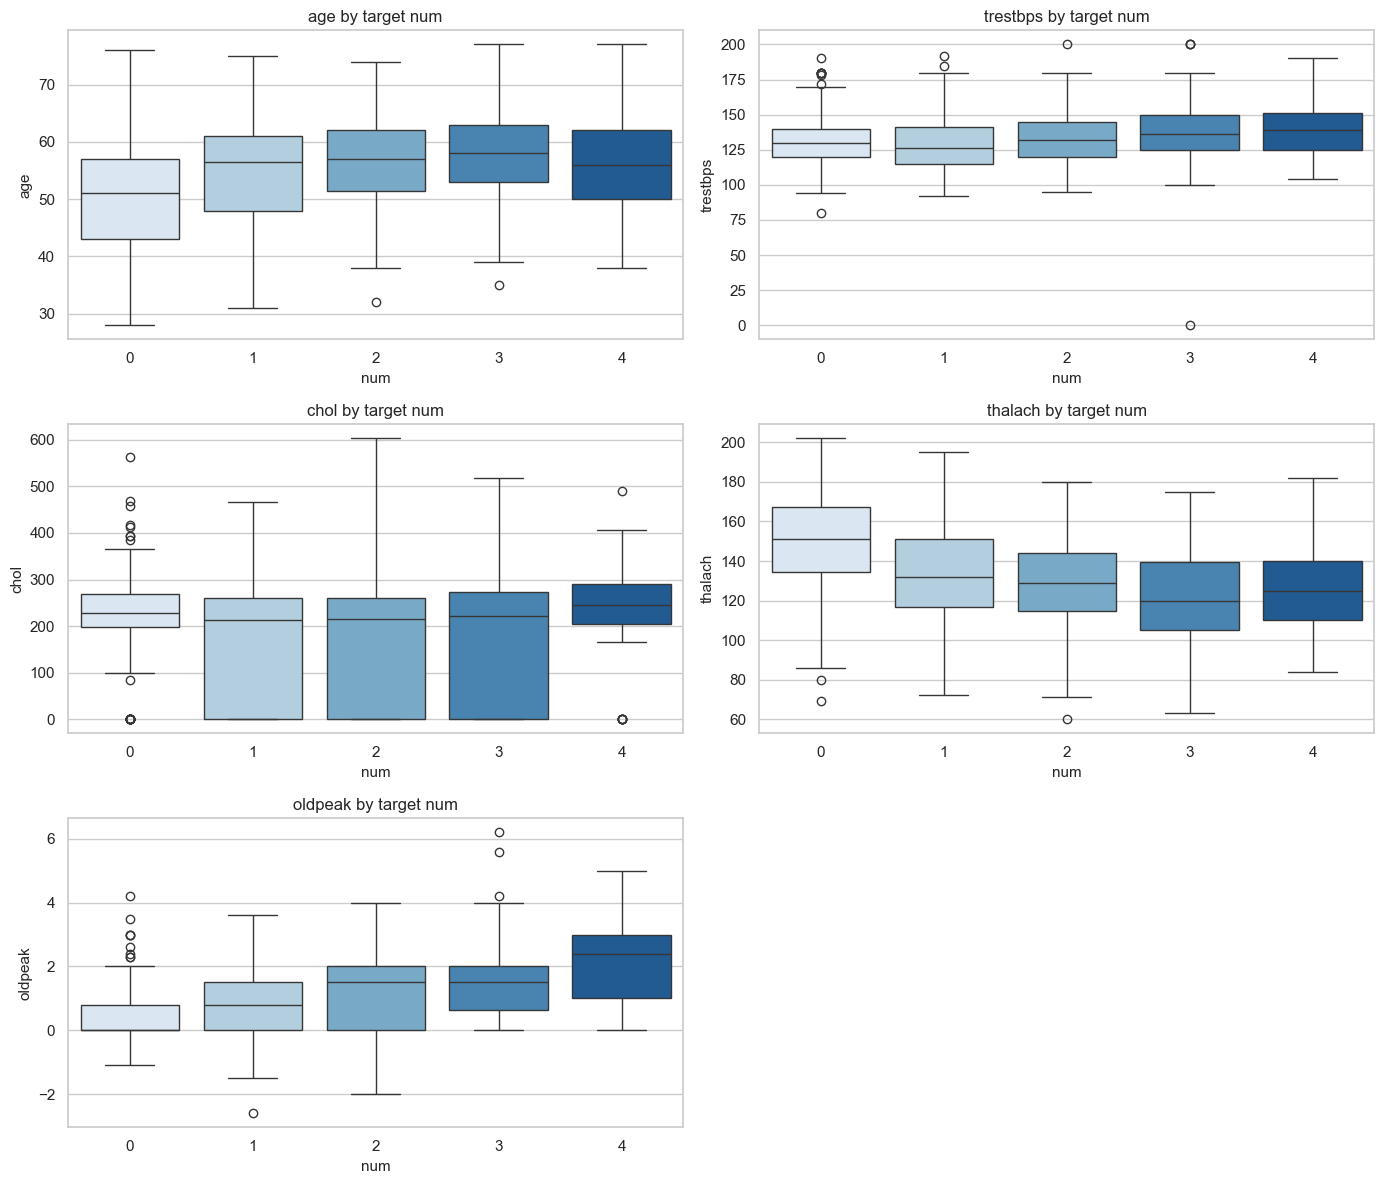

In [29]:
ncols = 2
nrows = int(np.ceil(len(quantitative_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, quantitative_features):
    sns.boxplot(data=df, x=target_col, y=col, palette="Blues", ax=ax)
    ax.set_title(f"{col} by target num")
    ax.set_xlabel("num")
    ax.set_ylabel(col)

for ax in axes[len(quantitative_features):]:
    ax.set_visible(False)

plt.tight_layout()


Feature: sex


num,0,1,2,3,4
sex,,,,,
0,144,23,11,11,5
1,267,173,124,124,38


num,0,1,2,3,4
sex,,,,,
0,0.742,0.119,0.057,0.057,0.026
1,0.368,0.238,0.171,0.171,0.052


Feature: cp


num,0,1,2,3,4
cp,,,,,
1,26,9,5,5,1
2,150,14,2,7,1
3,131,31,16,21,5
4,104,142,112,102,36


...

num,0,1,2,3,4
ca,,,,,
0,133,28,9,8,3
1,21,20,14,9,3
2,8,7,9,15,2
3,3,3,4,5,5
9,1,0,0,0,0
Missing,245,138,99,98,30


num,0,1,2,3,4
ca,,,,,
0,0.735,0.155,0.050,0.044,0.017
1,0.313,0.299,0.209,0.134,0.045
2,0.195,0.171,0.220,0.366,0.049
3,0.150,0.150,0.200,0.250,0.250
9,1.000,0.000,0.000,0.000,0.000
Missing,0.402,0.226,0.162,0.161,0.049


Feature: thal


num,0,1,2,3,4
thal,,,,,
1,2,0,1,1,0
2,1,0,0,0,0
3,138,30,14,12,2
4,0,0,0,1,0
5,0,1,2,0,0
6,11,10,14,7,4
7,38,59,39,44,12
Missing,221,96,65,70,25


num,0,1,2,3,4
thal,,,,,
1,0.500,0.000,0.250,0.250,0.000
2,1.000,0.000,0.000,0.000,0.000
3,0.704,0.153,0.071,0.061,0.010
4,0.000,0.000,0.000,1.000,0.000
5,0.000,0.333,0.667,0.000,0.000
6,0.239,0.217,0.304,0.152,0.087
7,0.198,0.307,0.203,0.229,0.062
Missing,0.463,0.201,0.136,0.147,0.052


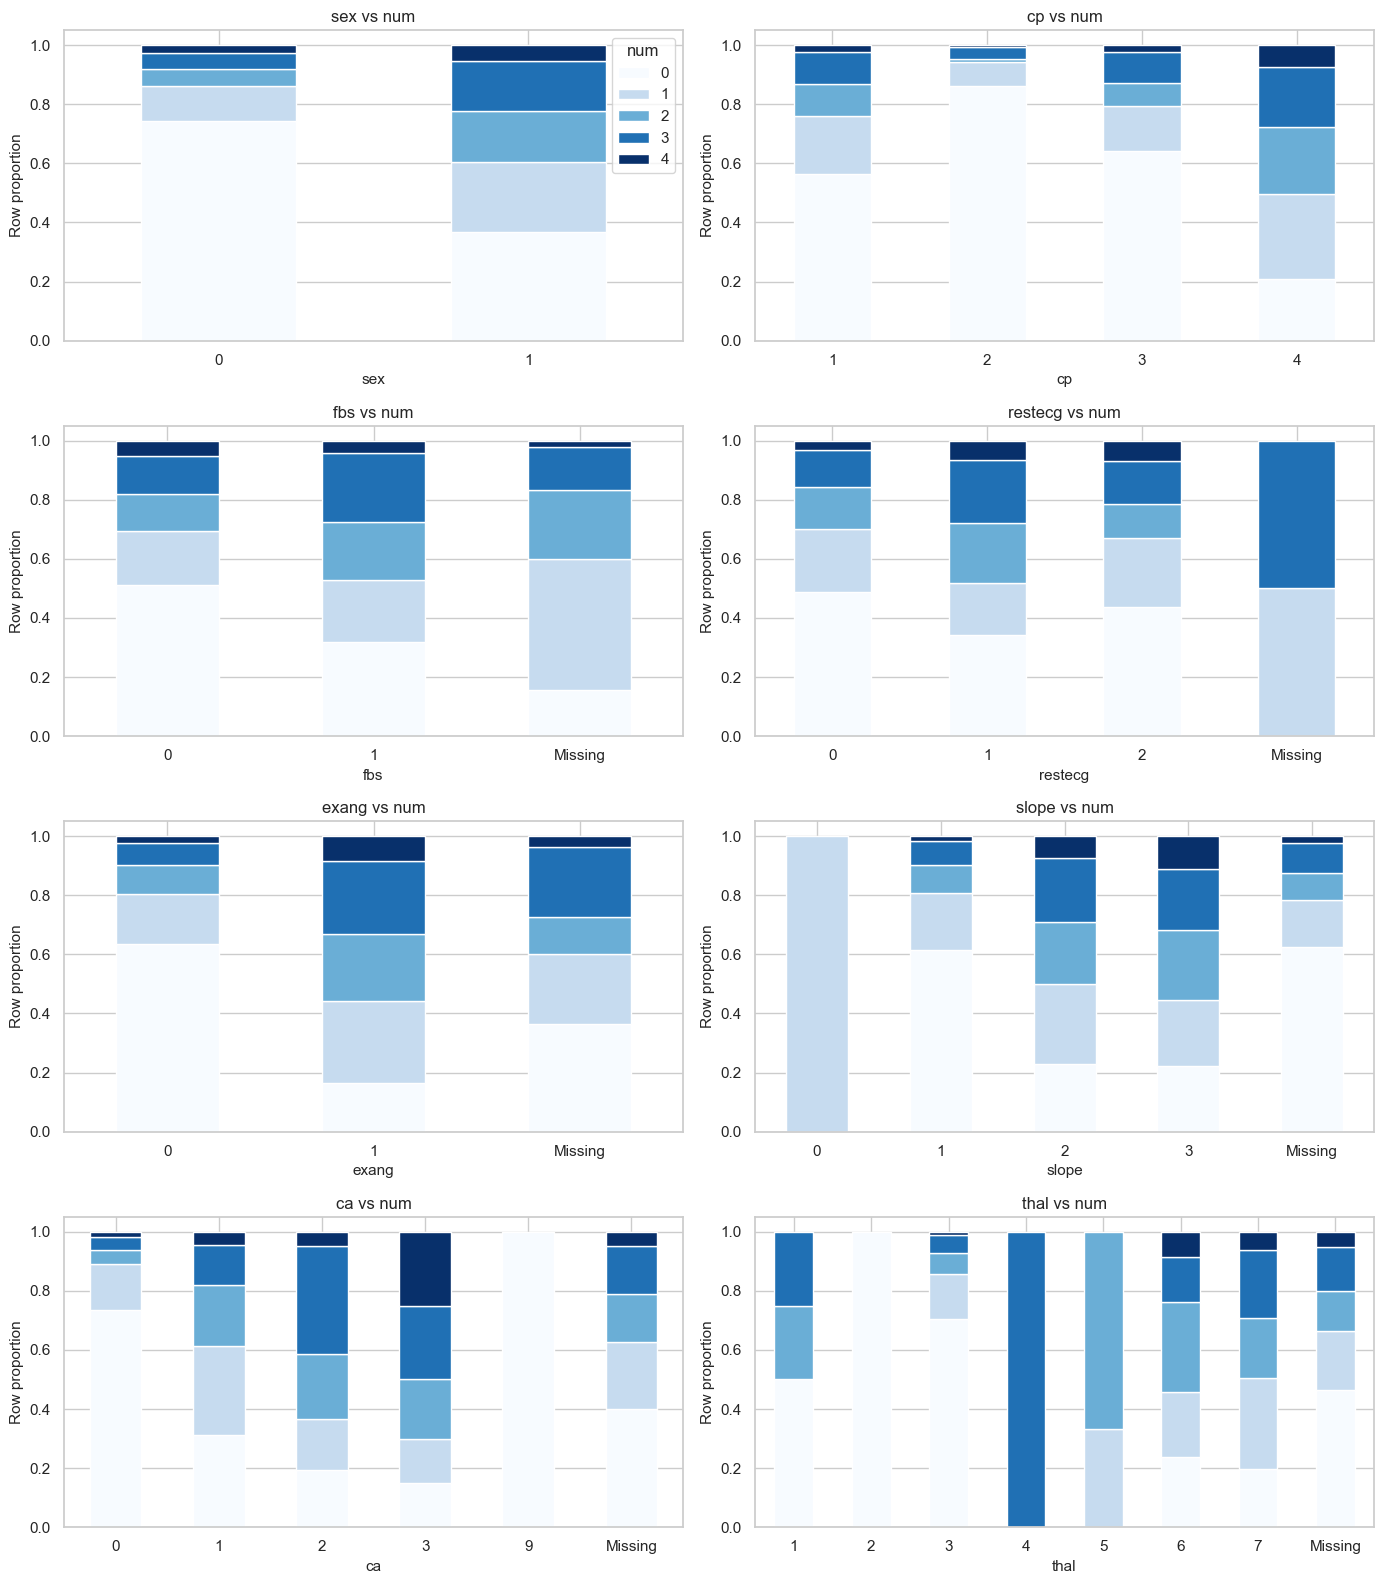

In [30]:
for col in categorical_features:
    formatted, order = prepare_categorical_plot_data(df[col])
    counts = pd.crosstab(formatted, df[target_col]).reindex(order)
    proportions = pd.crosstab(formatted, df[target_col], normalize="index").reindex(order)
    print(f"Feature: {col}")
    display(counts)
    display(proportions.round(3))

ncols = 2
nrows = int(np.ceil(len(categorical_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)
first_col = categorical_features[0]

for ax, col in zip(axes, categorical_features):
    formatted, order = prepare_categorical_plot_data(df[col])
    proportions = pd.crosstab(formatted, df[target_col], normalize="index").reindex(order)
    proportions.plot(kind="bar", stacked=True, colormap="Blues", ax=ax, legend=(col == first_col))
    ax.set_title(f"{col} vs num")
    ax.set_xlabel(col)
    ax.set_ylabel("Row proportion")
    ax.tick_params(axis="x", rotation=0)
    if col == first_col:
        ax.legend(title="num")

for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()


### Commentaire intermediaire

Les associations les plus prometteuses devront etre interpretees a la lumiere de deux contraintes :
- certaines variables sont tres informatives mais tres incompletes (`ca`, `thal`, `slope`) ;
- certaines variables categorielles ne sont pas parfaitement harmonisees entre sources.

Autrement dit, un signal visuel fort dans l'EDA ne signifie pas automatiquement qu'une variable sera simple a exploiter dans un modele robuste.


## 7. Correlations et redondances

Avant la modelisation, il est utile de verifier si certaines variables quantitatives sont tres redondantes entre elles. Une correlation elevee pourrait justifier un traitement particulier selon le type de modele retenu plus tard.


,age,trestbps,chol,thalach,oldpeak
age,1.000,0.244,-0.086,-0.366,0.258
trestbps,0.244,1.000,0.093,-0.105,0.162
chol,-0.086,0.093,1.000,0.236,0.048
thalach,-0.366,-0.105,0.236,1.000,-0.151
oldpeak,0.258,0.162,0.048,-0.151,1.000


No pair of quantitative variables exceeds an absolute correlation of 0.60.


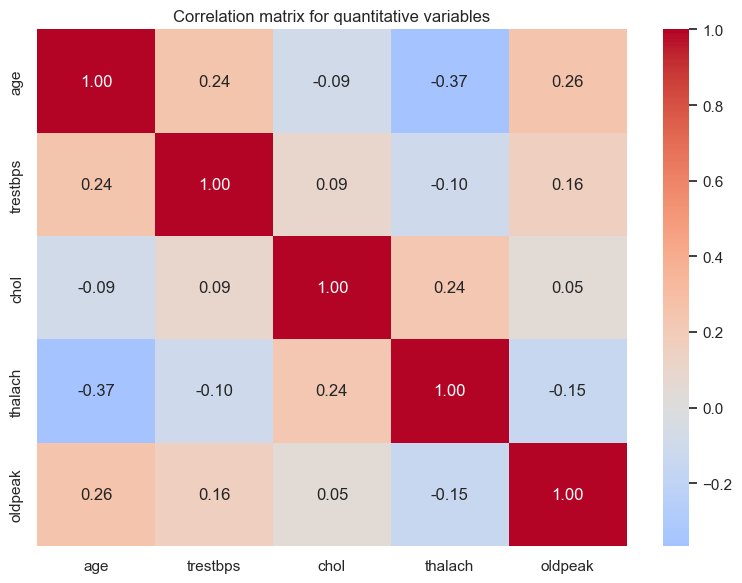

In [31]:
corr = df[quantitative_features].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation matrix for quantitative variables")
plt.tight_layout()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()

strong_pairs = high_corr_pairs.query("abs_correlation >= 0.60").sort_values("abs_correlation", ascending=False)
if strong_pairs.empty:
    print("No pair of quantitative variables exceeds an absolute correlation of 0.60.")
else:
    display(strong_pairs)


## 8. Comparaison entre les sources / hopitaux

La comparaison par `source` est indispensable ici, car la fusion des bases n'est pas neutre. On cherche a verifier si les hopitaux ont des tailles d'echantillon comparables, des profils de cible similaires et des niveaux de qualite de donnees homogenes.


,n_obs,share
source,,
cleveland,303,0.329
hungarian,294,0.320
switzerland,123,0.134
va,200,0.217


source,cleveland,hungarian,switzerland,va
age,0.000,0.000,0.000,0.000
sex,0.000,0.000,0.000,0.000
cp,0.000,0.000,0.000,0.000
trestbps,0.000,0.300,1.600,28.000
chol,0.000,7.800,0.000,3.500
fbs,0.000,2.700,61.000,3.500
restecg,0.000,0.300,0.800,0.000
thalach,0.000,0.300,0.800,26.500
exang,0.000,0.300,0.800,26.500
oldpeak,0.000,0.000,4.900,28.000


num,0,1,2,3,4
source,,,,,
cleveland,0.541,0.182,0.119,0.116,0.043
hungarian,0.639,0.126,0.088,0.095,0.051
switzerland,0.065,0.390,0.260,0.244,0.041
va,0.255,0.280,0.205,0.210,0.050


age              trestbps                   chol          \
              mean median   std     mean  median    std    mean  median   
source                                                                    
cleveland   54.440 56.000 9.040  131.690 130.000 17.600 246.690 241.000   
hungarian   47.830 49.000 7.810  132.580 130.000 17.630 250.850 243.000   
switzerland 55.320 56.000 9.030  130.210 125.000 22.560   0.000   0.000   
va          59.350 60.000 7.810  133.760 130.000 21.540 178.750 216.000   

                    thalach                oldpeak               
                std    mean  median    std    mean median   std  
source                                                           
cleveland    51.780 149.610 153.000 22.880   1.040  0.800 1.160  
hungarian    67.660 139.130 140.000 23.590   0.590  0.000 0.910  
switzerland   0.000 121.560 121.000 25.980   0.650  0.300 1.060  
va          114.040 122.800 120.000 21.990   1.320  1.500 1.110

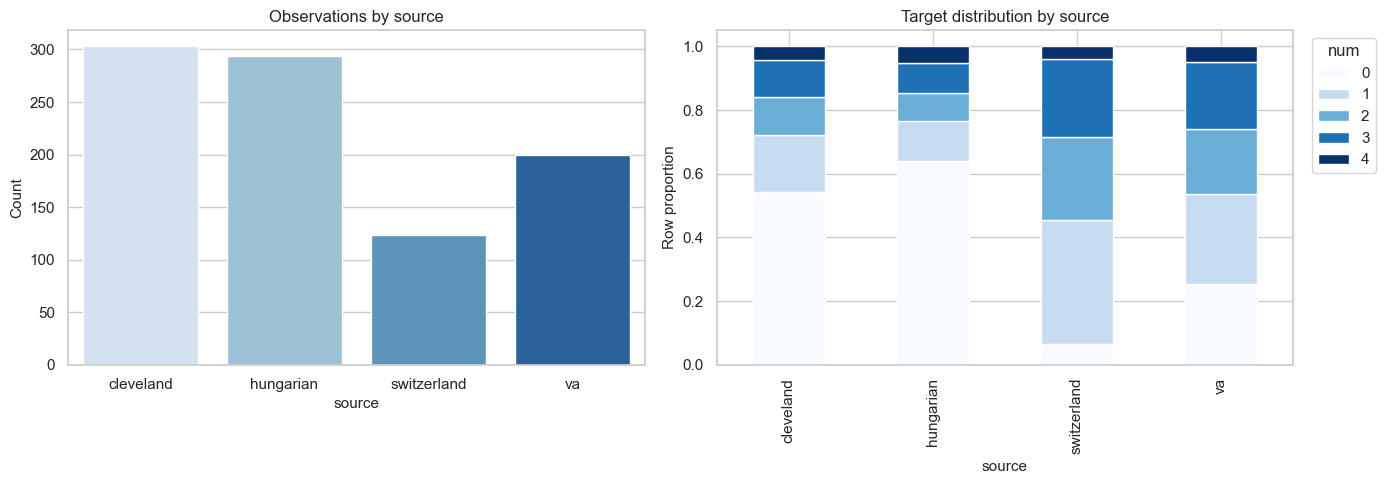

In [32]:
source_size = df[source_col].value_counts().sort_index().rename_axis("source").to_frame("n_obs")
source_size["share"] = source_size["n_obs"] / len(df)
display(source_size)

source_missing = (
    df.groupby(source_col, observed=True)[column_names]
    .agg(lambda series: series.isna().mean())
    .T
    .mul(100)
    .round(1)
)
display(source_missing)

source_target = pd.crosstab(df[source_col], df[target_col], normalize="index").round(3)
display(source_target)

source_stats = (
    df.groupby(source_col, observed=True)[quantitative_features]
    .agg(["mean", "median", "std"])
    .round(2)
)
display(source_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x=source_col, order=sorted(df[source_col].astype(str).unique()), palette="Blues", ax=axes[0])
axes[0].set_title("Observations by source")
axes[0].set_xlabel("source")
axes[0].set_ylabel("Count")

pd.crosstab(df[source_col], df[target_col], normalize="index").plot(kind="bar", stacked=True, colormap="Blues", ax=axes[1])
axes[1].set_title("Target distribution by source")
axes[1].set_xlabel("source")
axes[1].set_ylabel("Row proportion")
axes[1].legend(title="num", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


## 9. Discussion methodologique

### Pourquoi la fusion des bases est-elle pertinente ?

Fusionner Cleveland, Hungary, Switzerland et VA permet d'augmenter la taille d'echantillon disponible et d'evaluer le probleme sur un cadre plus riche qu'une seule sous-base. Ici, la fusion issue des fichiers locaux est particulierement utile car elle permet de conserver une cible multiclasse plus fidele au dataset d'origine.

### Quels risques cela pose-t-il ?

Les risques principaux sont les suivants :
- heterogeneite des valeurs manquantes selon la source ;
- heterogeneite de la distribution de la cible selon l'hopital ;
- codages non parfaitement harmonises pour certaines variables categorielles ;
- effet de site susceptible d'influencer les performances d'un modele.

### Les donnees semblent-elles de qualite homogene ?

Non. L'EDA montre au contraire une qualite tres variable d'une source a l'autre, avec des variables presque completes dans Cleveland mais tres lacunaires ailleurs, et avec quelques anomalies de codage dans les fichiers bruts.

### La classification multiclasse semble-t-elle faisable ?

Oui, dans la mesure ou les classes `1`, `2` et `3` disposent d'effectifs substantiels. La classe `4` reste rare, ce qui impose de la prudence. La piste multiclasse est donc faisable et justifiable, mais elle devra etre comparee a une version binaire plus simple.

### Quels problemes devront etre traites avant modelisation ?

- `valeurs manquantes` : plusieurs variables appellent soit une imputation soignee, soit une exclusion dans un scenario conservateur ;
- `desequilibre de classes` : surtout pour la classe `4` ;
- `encodage des variables` : les variables qualitatives codees numeriquement ne doivent pas etre traitees comme des variables continues ;
- `harmonisation des modalites` : certains codes observes dans les fichiers bruts ne correspondent pas exactement a la documentation ;
- `normalisation eventuelle` : utile pour certains modeles sur les variables quantitatives ;
- `validation du choix de cible` : comparaison rigoureuse entre la cible multiclasse et la cible binaire.


## 10. Tracabilite du chargement brut

Le chargement local repose prioritairement sur les fichiers bruts. Dans ce depot, `hungarian.data`, `switzerland.data` et `long-beach-va.data` ont pu etre parses directement au format 76 attributs. En revanche, le fichier `cleveland.data` local est corrompu en fin de fichier ; un fallback documente sur `processed.cleveland.data` a donc ete utilise pour cette source uniquement.

Ce compromis reste preferable a un chargement `ucimlrepo` pour ce projet, car il permet de controler explicitement la fusion et de conserver une cible multiclasse plus riche que dans certaines versions `processed` externes.


In [33]:
raw_inventory = pd.DataFrame({
    "source": list(raw_files.keys()),
    "raw_file": list(raw_files.values()),
    "raw_exists": [(DATA_DIR / filename).exists() for filename in raw_files.values()],
})

display(raw_inventory)
display(loading_report)


,source,raw_file,raw_exists
0,cleveland,cleveland.data,True
1,hungarian,hungarian.data,True
2,switzerland,switzerland.data,True
3,va,long-beach-va.data,True


,source,file_used,loader_used,rows,note
0,cleveland,processed.cleveland.data,processed fallback,303,raw file unusable locally (ValueError)
1,hungarian,hungarian.data,raw,294,raw file parsed successfully
2,switzerland,switzerland.data,raw,123,raw file parsed successfully
3,va,long-beach-va.data,raw,200,raw file parsed successfully


## 11. Conclusion et prochaines etapes

Cette EDA montre que la fusion des quatre sources est faisable et pertinente, mais qu'elle s'accompagne d'une heterogeneite importante en termes de qualite des donnees, de codages et de distribution de la cible. Le passage par les fichiers bruts locaux apporte une meilleure fidelite au probleme initial, en particulier pour l'etude de la cible multiclasse.

Les prochaines etapes avant modelisation sont donc :
- choisir une strategie de traitement des variables tres incomplètes ;
- harmoniser les modalites categorielles non documentees ;
- definir des variantes de jeu de donnees pour comparer un cadre conservateur et un cadre plus complet ;
- comparer ensuite la cible multiclasse et la cible binaire dans un protocole d'evaluation propre.


## 12. Interpretation detaillee des analyses realisees

Les resultats obtenus permettent deja de tirer plusieurs conclusions solides.

### 1. Taille et structure globale du dataset

La base de travail contient **920 patients** issus de quatre sources : Cleveland (**303**), Hungary (**294**), VA Long Beach (**200**) et Switzerland (**123**). La fusion est donc suffisamment large pour justifier une etude serieuse, mais les sous-bases restent de tailles inegales.

### 2. La cible multiclasse est reellement exploitable

Avec la reconstruction depuis les fichiers locaux, la cible `num` est distribuee comme suit : **411** observations en classe `0`, **196** en classe `1`, **135** en classe `2`, **135** en classe `3` et **43** en classe `4`. Cela signifie que la classe `4` est rare, mais que les classes intermediaires ne sont pas anecdotiques. D'un point de vue methodologique, cela renforce l'idee qu'une classification multiclasse est faisable et merite d'etre testee avant toute simplification binaire.

### 3. La fusion des sources cree une heterogeneite reelle

Les distributions de la cible varient fortement selon la source. Hungary contient une majorite nette de `num = 0`, alors que Switzerland est tres majoritairement composee de patients malades. VA presente aussi une repartition bien plus chargee en classes positives que Cleveland. Cette heterogeneite est importante : elle signifie qu'une bonne performance globale pourrait masquer des comportements tres differents selon l'hopital.

### 4. La qualite des donnees est tres inegale selon les variables et les sources

Trois variables ressortent comme problematiques a l'echelle globale : `ca` (environ **66 %** de valeurs manquantes), `thal` (environ **52 %**) et `slope` (environ **33 %**). De plus, ce manque d'information n'est pas uniforme : `ca` est presque completement absent hors de Cleveland, `fbs` est tres lacunaire en Switzerland, et VA cumule des taux eleves de valeurs manquantes sur `trestbps`, `thalach`, `exang` et `oldpeak`. Ces constats impliquent qu'un pipeline unique et naive d'imputation risque d'etre insuffisant.

### 5. Les fichiers bruts revelent aussi des anomalies de codage

L'audit des modalites observees montre des valeurs non documentees, notamment `ca = 9`, `slope = 0` et plusieurs modalites de `thal` absentes de la documentation standard. Ce point est important : avant modelisation, il faudra decider si ces modalites doivent etre recodees en `NaN`, regroupees, ou conservees comme indicateurs specifiques de certaines sources.

### 6. Les signaux cliniques attendus apparaissent deja dans l'EDA

Les analyses bivariees montrent des tendances coherentes avec la litterature clinique : les patients avec des classes `num` plus elevees tendent a avoir une frequence cardiaque maximale plus basse (`thalach`), un `oldpeak` plus eleve, une proportion plus forte de douleur thoracique asymptomatique (`cp = 4`) et davantage d'angine a l'effort (`exang = 1`). Les variables `ca`, `slope` et `thal` semblent informatives elles aussi, mais leur interpretation reste fragilisee par le manque de donnees et l'heterogeneite des codages.

### 7. Il n'y a pas de redondance lineaire massive entre variables quantitatives

La matrice de correlation ne montre pas de correlation tres forte entre les variables quantitatives. Le lien le plus net est une correlation negative moderee entre `age` et `thalach`. Cela signifie qu'a ce stade, la reduction de dimension pour cause de colinearite n'apparait pas comme une priorite.

En synthese, l'EDA valide l'interet du projet, justifie l'etude multiclasse, mais montre clairement que la qualite et l'homogeneite des donnees seront le vrai enjeu methodologique avant toute modelisation.


## 13. Preparation methodologique pour la suite du projet

L'objectif n'est toujours pas de lancer la modelisation finale, mais de preparer un cadre propre pour la suite. On construit donc ci-dessous :
- des recommandations de pretraitement par variable ;
- un scenario **conservateur** qui exclut les variables trop lacunaires ;
- un scenario **etendu** qui conserve davantage d'information clinique au prix d'un pretraitement plus exigeant ;
- une version **multiclasse** et une version **binaire** de la cible.


In [34]:
overall_missing_rate = df[all_feature_columns].isna().mean().sort_values()
conservative_features = overall_missing_rate[overall_missing_rate <= 0.10].index.tolist()
extended_features = all_feature_columns.copy()

df_multiclass = df[extended_features + [source_col, target_col]].copy()
df_binary = df[extended_features + [source_col, target_col]].copy()
df_binary["target_binary"] = (df_binary[target_col] > 0).astype(int)

feature_recommendations = []
for feature in quantitative_features:
    feature_recommendations.append({
        "variable": feature,
        "type": "quantitative",
        "missing_rate": missing_table.loc[feature, "pct_missing"],
        "recommended_treatment": "median imputation + optional scaling",
        "comment": "continuous clinical measurement",
    })

for feature in binary_features:
    feature_recommendations.append({
        "variable": feature,
        "type": "binary categorical",
        "missing_rate": missing_table.loc[feature, "pct_missing"],
        "recommended_treatment": "most frequent imputation + categorical handling",
        "comment": "do not treat as continuous",
    })

for feature in ["cp", "restecg"]:
    feature_recommendations.append({
        "variable": feature,
        "type": "multicategory categorical",
        "missing_rate": missing_table.loc[feature, "pct_missing"],
        "recommended_treatment": "categorical encoding after modality check",
        "comment": "low missingness but coded numerically",
    })

for feature in ["slope", "ca", "thal"]:
    feature_recommendations.append({
        "variable": feature,
        "type": "high-risk categorical",
        "missing_rate": missing_table.loc[feature, "pct_missing"],
        "recommended_treatment": "recode undocumented modalities, then compare exclusion vs explicit missing-category strategy",
        "comment": "high missingness and/or inconsistent coding across sources",
    })

feature_recommendations.append({
    "variable": source_col,
    "type": "source identifier",
    "missing_rate": 0.0,
    "recommended_treatment": "keep for diagnostics and sensitivity analyses; optional feature in a secondary model",
    "comment": "captures site effects rather than patient physiology",
})

preprocessing_plan = pd.DataFrame(feature_recommendations).sort_values("missing_rate", ascending=False)
display(preprocessing_plan)

print("Conservative feature set:")
print(conservative_features)
print()
print("Extended feature set:")
print(extended_features)

dataset_variants = pd.DataFrame([
    {
        "scenario": "multiclass_conservative",
        "target": "num (0-4)",
        "n_features": len(conservative_features),
        "features": ", ".join(conservative_features),
        "main_goal": "stability and interpretability",
    },
    {
        "scenario": "multiclass_extended",
        "target": "num (0-4)",
        "n_features": len(extended_features),
        "features": ", ".join(extended_features),
        "main_goal": "retain richer clinical information",
    },
    {
        "scenario": "binary_conservative",
        "target": "target_binary (0 vs 1-4)",
        "n_features": len(conservative_features),
        "features": ", ".join(conservative_features),
        "main_goal": "robust baseline benchmark",
    },
    {
        "scenario": "binary_extended",
        "target": "target_binary (0 vs 1-4)",
        "n_features": len(extended_features),
        "features": ", ".join(extended_features),
        "main_goal": "performance-oriented comparison",
    },
])
display(dataset_variants)

target_strategy = pd.DataFrame([
    {
        "target_version": "multiclass",
        "definition": "num with classes 0, 1, 2, 3, 4",
        "advantage": "closest to the original clinical framing",
        "risk": "rarer classes, harder evaluation",
    },
    {
        "target_version": "binary",
        "definition": "0 vs 1-4",
        "advantage": "simpler and more stable classification task",
        "risk": "loss of granularity",
    },
])
display(target_strategy)


,variable,type,missing_rate,recommended_treatment,comment
11,ca,high-risk categorical,0.663,"recode undocumented modalities, then compare e...",high missingness and/or inconsistent coding ac...
12,thal,high-risk categorical,0.518,"recode undocumented modalities, then compare e...",high missingness and/or inconsistent coding ac...
10,slope,high-risk categorical,0.335,"recode undocumented modalities, then compare e...",high missingness and/or inconsistent coding ac...
6,fbs,binary categorical,0.098,most frequent imputation + categorical handling,do not treat as continuous
4,oldpeak,quantitative,0.067,median imputation + optional scaling,continuous clinical measurement
1,trestbps,quantitative,0.064,median imputation + optional scaling,continuous clinical measurement
7,exang,binary categorical,0.060,most frequent imputation + categorical handling,do not treat as continuous
3,thalach,quantitative,0.060,median imputation + optional scaling,continuous clinical measurement
2,chol,quantitative,0.033,median imputation + optional scaling,continuous clinical measurement
9,restecg,multicategory categorical,0.002,categorical encoding after modality check,low missingness but coded numerically


Conservative feature set:
['age', 'sex', 'cp', 'restecg', 'chol', 'thalach', 'exang', 'trestbps', 'oldpeak', 'fbs']

Extended feature set:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


,scenario,target,n_features,features,main_goal
0,multiclass_conservative,num (0-4),10,"age, sex, cp, restecg, chol, thalach, exang, t...",stability and interpretability
1,multiclass_extended,num (0-4),13,"age, trestbps, chol, thalach, oldpeak, sex, cp...",retain richer clinical information
2,binary_conservative,target_binary (0 vs 1-4),10,"age, sex, cp, restecg, chol, thalach, exang, t...",robust baseline benchmark
3,binary_extended,target_binary (0 vs 1-4),13,"age, trestbps, chol, thalach, oldpeak, sex, cp...",performance-oriented comparison


,target_version,definition,advantage,risk
0,multiclass,"num with classes 0, 1, 2, 3, 4",closest to the original clinical framing,"rarer classes, harder evaluation"
1,binary,0 vs 1-4,simpler and more stable classification task,loss of granularity


## 14. Suite logique du projet

A partir de ce notebook, la suite du projet peut etre organisee proprement en trois temps :

1. **Notebook de pretraitement**
   Construire les pipelines correspondant aux scenarios conservateur et etendu, avec harmonisation des modalites problematiques, imputation explicite et creation eventuelle d'indicateurs de missingness.

2. **Notebook de modelisation comparee**
   Comparer au minimum une formulation multiclasse et une formulation binaire, en gardant un protocole d'evaluation cohérent avec le desequilibre des classes.

3. **Analyse de robustesse**
   Verifier si les performances sont homogènes selon les sources, et tester eventuellement l'effet de la variable `source` comme information additionnelle ou comme axe de diagnostic.

A ce stade, le projet dispose donc d'une base EDA solide, interpretee, et directement exploitable pour passer a une phase de pretraitement puis de modelisation argumentee.
